# Lab 4: Differential Kinematics (worked solutions)

Companion to `DifferentialKinematicsTemplate.ipynb` and `pdfs/Differential_Kinematics.pdf`.
Layout: **Task → Solution → How it works → Example / check**.

**The idea.** Forward kinematics is nonlinear: $x = T(q)$. Differentiating gives a *linear* relation between
velocities: $\;v = J(q)\,\dot q$, with the **geometric Jacobian** $J(q)$ (6×6 for the myCobot 280). $v = [\dot p;\ \omega]$
stacks linear velocity (m/s) and angular velocity (rad/s) of the end effector, both in the base frame. Everything
in this lab follows from that one equation:

| question | use |
|---|---|
| joints move → how does the tool move? | $v = J\dot q$ |
| I want the tool to move like this → which joint speeds? | $\dot q = J^{-1}v$ (resolved rate) |
| where does this fail? | $J$ loses rank: **singularity** |
| how good is the arm in this pose? | singular values, manipulability |

**Data in this notebook.** The template needs `mycobot_280_gazebo.urdf`; until it is in the repo, the fallback URDF
is used (`labpaths` prints a warning). The fallback is almost certainly the same robot geometry as the course file (Lab 5
reproduces the controller's calibration with it to six digits), so the numbers quoted in the text should hold with the
course file too; if they don't, trust the printed output. Tasks 19–20 talk to the real robot; they were **not executed** here and are off by
default.

## Setup

In [1]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
import labpaths          # solutions/labpaths.py: repo root on sys.path + URDF location
from helperFunctions import (
    rpy_to_rot, rpy_to_transform, rot_to_vec,
    poseError, calculate_poseerror, transform_to_pipi,
)

np.set_printoptions(precision=4, suppress=True)

---
## Task 1: Import the URDF

In [2]:
mycobot_urdf_path = labpaths.urdf_path()     # template: os.path.join(os.getcwd(), 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)

NOTE: mycobot_280_gazebo.urdf not found in the repo root.
      Using the fallback /home/mano-ub22/TUD/cobots/ros2_ws/src/mycobot_description/urdf/mycobot_280_pi/mycobot_280_pi.urdf
      (same kinematic chain as far as checked, see solutions/labpaths.py)
ERobot: firefighter, 6 joints (RRRRRR), geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ g_base         │       │ BASE   │ SE3()                                               │
│    1 │ joint1         │       │ g_base │ SE3()                                               │
│    2 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    3 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    

/tmp/ipykernel_62073/3513415727.py:2: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


**How it works** (as in Lab 3): `Robot.URDF(path)` builds the tree, `mycobot.links` is a list of links. Notice that
the joint variable of joint *i* lives in the link named `joint(i+1)`: e.g. the URDF joint `joint2_to_joint1` (which
rotates joint 1) belongs to the link `joint2`. Task 5 uses that.

---
## Task 2: A reference configuration

In [3]:
bodyname = 'joint6_flange'

# Reference configuration (radians) — away from singular stretched-out poses
q_ref = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0])

# Verify with FK
T_ref = mycobot.fkine(q_ref, end=bodyname)
print('Reference EE pose:\n', T_ref)
print('EE position (m):', T_ref.A[:3, 3])

Reference EE pose:
   -3.181e-06 -1        -1.837e-06  0.2472    
  -0.866     1.837e-06  0.5      -0.04082   
  -0.5       3.181e-06 -0.866     0.1771    
   0         0         0         1         

EE position (m): [ 0.2472 -0.0408  0.1771]


**How it works**
- `q_ref` in degrees: [0, −45, −45, 0, 30, 0]. Two things keep it away from singularities (Tasks 11–12):
  the elbow is bent (q3 = −45°; q3 = 0 would be the stretched-arm singularity) and joint 5 is 30° from ±90°
  (the wrist singularity, where the axes of joints 4 and 6 line up).
- `fkine(q, end=bodyname)` returns the flange pose as `SE3`; `.A` its 4×4 array; `[:3, 3]` the position.

---
## The geometric Jacobian
## Task 3: The base-frame Jacobian

In [4]:
J0 = mycobot.jacob0(q_ref, end=bodyname)   # base-frame geometric Jacobian at q_ref
print('J0 shape:', J0.shape)
print('J0:\n', J0)

J0 shape: (6, 6)
J0:
 [[ 0.0408 -0.0386  0.0395  0.0395  0.      0.    ]
 [ 0.2472 -0.     -0.     -0.      0.0395  0.    ]
 [ 0.      0.2472  0.1692  0.0732  0.0228  0.    ]
 [ 0.     -0.     -0.     -0.      1.     -0.    ]
 [ 0.     -1.     -1.     -1.     -0.      0.5   ]
 [ 1.     -0.     -0.     -0.      0.     -0.866 ]]


**How it works**
- `robot.jacob0(q, end=link)` = Jacobian of the frame `link`, with velocities expressed in the **base** frame
  ("0"). `robot.jacobe(q, end=link)` gives it in the end-effector frame ("e") (Task 8).
- Shape 6×6: **rows** = `[vx, vy, vz, ωx, ωy, ωz]`, **columns** = joints 1–6. Column *i* is "what the tool does
  when joint *i* turns at 1 rad/s and all others stand still".
- Read column 1 of the printed matrix: linear part `[0.0408, 0.2472, 0]`, angular part `[0, 0, 1]`. Joint 1 turns
  about the vertical z-axis (angular velocity `[0, 0, 1]`), and the tool sits about 0.25 m in front of that axis,
  so it moves sideways (y) at 0.25 m/s per rad/s. This is $\omega \times r$, the same as the cross product in the
  next task.

---
## Task 4: How the controller builds the Jacobian
For each revolute joint $i$ the geometric Jacobian column is
$$ J_i = \begin{bmatrix} z_i \times (p_e - p_i) \\ z_i \end{bmatrix} $$
with $z_i$ the joint axis (unit vector, base frame), $p_i$ a point on that axis (the joint position), and $p_e$ the
end-effector position. Intuition: turning about axis $z_i$ at rate $\dot q_i$ gives the tool point a velocity
$\dot q_i\, z_i \times r$ where $r = p_e - p_i$ is the lever arm, and an angular velocity $\dot q_i z_i$.

The controller (`_fk_and_jacobian`) walks the URDF chain: multiply the fixed `origin` transform, record $p_i$ and
$z_i$, multiply the joint rotation, repeat. Here is the same thing with the toolbox's link frames, as a function:

In [5]:
def jacobian_from_frames(q, robot=mycobot, end=bodyname):
    """Geometric Jacobian in the base frame, built column by column from the joint frames."""
    T_e = robot.fkine(q, end=end).A
    p_e = T_e[:3, 3]
    J = np.zeros((6, robot.n))
    for link in robot.links:
        if link.isjoint:                          # only links that carry a joint variable
            T_i = robot.fkine(q, end=link.name).A # frame of this joint
            z_i = T_i[:3, 2]                      # joint axis = 3rd column of the rotation block
            p_i = T_i[:3, 3]                      # joint position = last column
            J[:3, link.jindex] = np.cross(z_i, p_e - p_i)
            J[3:, link.jindex] = z_i
    return J

J_manual = jacobian_from_frames(q_ref)
print('matches jacob0 at q_ref:', np.allclose(J_manual, J0))
q_other = np.array([0.3, -0.4, 0.2, 0.5, -0.6, 0.7])
print('matches jacob0 at another q:', np.allclose(jacobian_from_frames(q_other), mycobot.jacob0(q_other, end=bodyname)))

matches jacob0 at q_ref: True
matches jacob0 at another q: True


**How it works**
- `link.isjoint` is `True` for links that have a movable joint, `link.jindex` is that joint's index (0…5).
- `T_i[:3, 2]` is the **third column of the rotation block** = the frame's z-axis in base coordinates. In the URDF each
  joint rotates about its local z, so this is the joint axis $z_i$ (the PDF writes this as $H_i(1{:}3, 3)$).
- `T_i[:3, 3]` is the frame origin = $p_i$.
- `np.cross(a, b)` is the cross product $a \times b$.
- `J[:3, k] = ...` fills rows 0–2 of column *k*; `J[3:, k] = ...` rows 3–5.
- The check returns `True`: the toolbox's `jacob0` **is** this construction. Understanding this loop is the point
  of the task: it is what runs inside the robot controller.

**Example: the same formula for a 2-link planar arm** (the PDF's Fig. 1), symbolic:

In [6]:
import sympy as sp

t1, t2, a1, a2 = sp.symbols('theta1 theta2 a1 a2')
x = a1*sp.cos(t1) + a2*sp.cos(t1 + t2)
y = a1*sp.sin(t1) + a2*sp.sin(t1 + t2)
J_planar = sp.Matrix([x, y]).jacobian(sp.Matrix([t1, t2]))     # partial derivatives d(x,y)/d(theta1,theta2)
sp.pprint(sp.simplify(J_planar))
print('det J =', sp.simplify(J_planar.det()))                  # a1*a2*sin(theta2)

⎡-a₁⋅sin(θ₁) - a₂⋅sin(θ₁ + θ₂)  -a₂⋅sin(θ₁ + θ₂)⎤
⎢                                               ⎥
⎣a₁⋅cos(θ₁) + a₂⋅cos(θ₁ + θ₂)   a₂⋅cos(θ₁ + θ₂) ⎦
det J = a1*a2*sin(theta2)


- `sp.symbols(...)` creates algebraic variables, `Matrix.jacobian(vars)` differentiates every entry.
- $\det J = a_1 a_2\sin\theta_2$: zero when $\theta_2 = 0$ or $\pi$ (arm fully **stretched** or **folded**): both links
  are in one line, and the tool cannot move along that line. This is the elbow singularity, the same thing that
  happens to the myCobot when joint 3 is 0.

---
## Task 5: Verify one Jacobian column

In [7]:
# Extract the FK and verify one Jacobian column manually
T_ee = mycobot.fkine(q_ref, end=bodyname).A
p_ee = T_ee[:3, 3]

# Joint 1 rotates inside the link 'joint2' (URDF joint 'joint2_to_joint1'), about the local z-axis
T_j1 = mycobot.fkine(q_ref, end='joint2').A
z_1 = T_j1[:3, 2]   # world-frame axis of joint 1
p_1 = T_j1[:3, 3]   # world-frame position of joint 1

J_col1_linear = np.cross(z_1, p_ee - p_1)   # linear part: z x (p_e - p_1)
J_col1_angular = z_1                        # angular part: z

print('z_1:', z_1, ' p_1:', p_1)
print('Manual J column 1 (linear):', J_col1_linear)
print('Manual J column 1 (angular):', J_col1_angular)
print('jacob0 column 1:', J0[:, 0])
print('equal:', np.allclose(np.hstack([J_col1_linear, J_col1_angular]), J0[:, 0]))

z_1: [0. 0. 1.]  p_1: [0.     0.     0.1396]
Manual J column 1 (linear): [ 0.0408  0.2472 -0.    ]
Manual J column 1 (angular): [0. 0. 1.]
jacob0 column 1: [0.0408 0.2472 0.     0.     0.     1.    ]
equal: True


**How it works**
- **Which frame is joint 1?** From the URDF/ETS table: `joint2 | SE3(0, 0, h) ⊕ Rz(q0)`. The first joint rotates about
  the z-axis of the frame located at height *h* above the base. So $z_1 = [0, 0, 1]$ and $p_1 = [0, 0, h]$ ($h$ = 0.13956
  m in the fallback URDF, 0.13122 m in the DH table of Lab 2).
- $p_e - p_1$ is the lever arm from that axis to the flange; `np.cross(z_1, lever)` rotates it by 90° about z and
  scales by its horizontal length. `np.hstack` joins the two 3-vectors into one 6-vector for the comparison.
- The equality confirms formula (6) of the PDF.

---
## Joint velocities ↔ Cartesian twist
## Task 6: Joint velocity → twist

In [8]:
qdot = np.array([0.1, -0.2, 0.15, 0.0, 0.1, -0.05])  # rad/s

twist = J0 @ qdot   # v = J(q) qdot

print('Linear velocity (m/s):', twist[:3])
print('Angular velocity (rad/s):', twist[3:])

Linear velocity (m/s): [ 0.0177  0.0287 -0.0218]
Angular velocity (rad/s): [0.1    0.025  0.1433]


**How it works / interpretation**
- `J0 @ qdot`: (6×6) @ (6,) → (6,). It is the sum of the columns weighted by the joint speeds.
- Result: the tool moves at about 1.8 cm/s in x, 2.9 cm/s in y, −2.2 cm/s in z, and turns at 0.1 rad/s about x,
  0.025 about y, 0.143 about z (all in the **base** frame).
- Angular velocity is a rotation rate about an axis. It is **not** the derivative of roll/pitch/yaw angles.

**Check by finite differences:** move the joints a tiny bit and compare the change of the FK pose

In [9]:
h = 1e-6
p_a = mycobot.fkine(q_ref, end=bodyname).A[:3, 3]
p_b = mycobot.fkine(q_ref + qdot * h, end=bodyname).A[:3, 3]
print('finite-difference linear velocity:', (p_b - p_a) / h)
print('J @ qdot linear part             :', twist[:3])

finite-difference linear velocity: [ 0.0177  0.0287 -0.0218]
J @ qdot linear part             : [ 0.0177  0.0287 -0.0218]


- $(p(q + \dot q h) - p(q))/h \to J_p\dot q$ as $h \to 0$: the Jacobian is exactly that derivative.

---
## Task 7: Twist → joint velocities

In [10]:
# Desired Cartesian twist: small linear motion + small rotation
v_desired = np.array([0.05, 0.02, 0.0, 0.0, 0.0, 0.1])  # [vx, vy, vz, wx, wy, wz]

qdot_resolved = np.linalg.solve(J0, v_desired)   # solve J qdot = v_d

print('Required joint velocities (rad/s):', qdot_resolved)
print('check J @ qdot = v_d:', np.allclose(J0 @ qdot_resolved, v_desired))

Required joint velocities (rad/s): [ 0.0809 -0.6038  1.1032 -0.5104 -0.     -0.0221]
check J @ qdot = v_d: True


**How it works**
- `np.linalg.solve(J0, v)` solves the linear system $J\dot q = v$. Mathematically that is $\dot q = J^{-1}v$, but
  `solve` is faster and more accurate than `np.linalg.inv(J0) @ v`, and it fails loudly (`LinAlgError`) for an exactly
  singular matrix.
- The result has entries up to about 1.1 rad/s for a 5 cm/s + 0.1 rad/s twist: the arm has to swing its joints
  quickly to produce a small tool motion in this direction because $J$ is only moderately well conditioned here
  (condition number ≈ 61, next tasks). The controller caps joint speed (≈ 2.6 rad/s), so this would already be a large
  fraction of it.
- The order of the twist matters: `[vx, vy, vz, wx, wy, wz]` = **linear first, angular second** (the toolbox
  convention, eq. (7) of the PDF). Other libraries use the opposite order.

---
## Task 8: Jacobian in the end-effector frame
$$ J_e = \begin{bmatrix} R^T & 0\\ 0 & R^T\end{bmatrix} J_0 $$

In [11]:
R_ee = T_ee[:3, :3]

# Build the 6x6 block-diagonal rotation transform
T_block = np.zeros((6, 6))
T_block[:3, :3] = R_ee.T   # rotates linear velocity from the base frame into the EE frame
T_block[3:, 3:] = R_ee.T   # same for angular velocity

J_ee_manual = T_block @ J0

# Compare with toolbox
J_ee_toolbox = mycobot.jacobe(q_ref, end=bodyname)

print('Manual Je:\n', J_ee_manual)
print('Toolbox Je:\n', J_ee_toolbox)
print('Match:', np.allclose(J_ee_manual, J_ee_toolbox))

Manual Je:
 [[-0.2141 -0.1236 -0.0846 -0.0366 -0.0456  0.    ]
 [-0.0408  0.0386 -0.0395 -0.0395 -0.      0.    ]
 [ 0.1236 -0.2141 -0.1465 -0.0634  0.      0.    ]
 [-0.5     0.866   0.866   0.866  -0.     -0.    ]
 [ 0.      0.      0.      0.     -1.      0.    ]
 [-0.866  -0.5    -0.5    -0.5    -0.      1.    ]]
Toolbox Je:
 [[-0.2141 -0.1236 -0.0846 -0.0366 -0.0456  0.    ]
 [-0.0408  0.0386 -0.0395 -0.0395 -0.      0.    ]
 [ 0.1236 -0.2141 -0.1465 -0.0634  0.      0.    ]
 [-0.5     0.866   0.866   0.866   0.      0.    ]
 [ 0.      0.      0.      0.     -1.      0.    ]
 [-0.866  -0.5    -0.5    -0.5    -0.      1.    ]]
Match: True


**How it works**
- A vector $a$ in the base frame has coordinates $R^Ta$ in the end-effector frame ($R$ = orientation of the
  EE, columns are the EE axes in base coordinates; $R^{-1} = R^T$). The same rotation applies to the linear and the
  angular part, hence two copies of $R^T$ on the diagonal of a 6×6 matrix.
- `np.zeros((6, 6))` creates the empty matrix; `T_block[:3, :3] = ...` writes the upper-left block.
- Use $J_e$ when you want to command velocities along the **tool's own axes** (e.g. "move 1 cm along the tool z"),
  e.g. for camera-based control; $J_0$ for velocities in the robot base frame.
- Singular values are the same for both ($R^T$ is orthogonal), so singularity analysis does not care which one you use.

---
## Singularity analysis
## Task 9: Rank and determinant at the reference configuration

In [12]:
rank_ref = np.linalg.matrix_rank(J0)   # number of independent columns
det_ref = np.linalg.det(J0)

print(f'Rank at q_ref: {rank_ref}')
print(f'Determinant at q_ref: {det_ref:.6e}')

Rank at q_ref: 6
Determinant at q_ref: -1.604657e-03


**How it works**
- `np.linalg.matrix_rank(J)` counts singular values above a small tolerance: rank 6 = all six twist directions can
  be produced.
- `np.linalg.det(J)` = volume factor of the map $\dot q \mapsto v$: 0 exactly when the Jacobian is singular.
- Rank 6 and $\det \ne 0$: not singular. **But** the value $-1.6\cdot10^{-3}$ looks tiny and is not a useful
  yardstick: $J$ mixes m/s and rad/s, so its determinant has no natural scale. To judge *how close* to singular a pose
  is, use the singular values / condition number (Task 10).

---
## Task 10: Singular value decomposition

In [13]:
U, sigma, Vt = np.linalg.svd(J0)

print('Singular values:', sigma)
print('Smallest singular value:', sigma[-1])
print('Condition number:', sigma[0] / sigma[-1])

Singular values: [1.8534 1.296  1.001  0.1773 0.1248 0.0302]
Smallest singular value: 0.030159682716723646
Condition number: 61.45248220794283


**How it works**
- SVD writes $J = U\Sigma V^T$ with orthogonal $U$, $V$ and $\Sigma = \operatorname{diag}(\sigma_1 \ge \dots \ge \sigma_6 \ge 0)$.
  `np.linalg.svd` returns `U`, the singular values as a 1D array `sigma` (sorted, largest first) and `Vt` = $V^T$.
- Meaning: a unit joint-velocity vector along the *i*-th column of $V$ produces a tool twist of size $\sigma_i$
  along the *i*-th column of $U$. **Large σ = the arm moves the tool easily in that direction; small σ = it barely
  can.** $\sigma_{min} \to 0$ means a direction is lost: singularity.
- Condition number $\sigma_{max}/\sigma_{min}$: how uneven the arm is. Here 1.85 / 0.030 ≈ 61. Joint speeds needed for
  the weakest direction are 61 times higher than for the strongest.

**Example: the meaning of U and V**

In [14]:
i = 5                                                    # weakest direction (index 5 = 6th singular value)
print('J @ v_i      =', J0 @ Vt[i])                     # v_i = i-th right singular vector (row i of Vt)
print('sigma_i * u_i =', sigma[i] * U[:, i])             # u_i = i-th left singular vector
print('weakest twist direction u_6:', U[:, i])

J @ v_i      = [-0.0256  0.01   -0.012  -0.0001 -0.0023 -0.0014]
sigma_i * u_i = [-0.0256  0.01   -0.012  -0.0001 -0.0023 -0.0014]
weakest twist direction u_6: [-0.85    0.3316 -0.3993 -0.004  -0.0769 -0.0461]


- The two lines are equal. The weakest twist direction $u_6$ is mostly a translation along the base x-axis
  (−0.85) combined with y and z components: from this pose the arm is worst at moving the tool in exactly that direction.

---
## Task 11: A singular configuration

In [15]:
# Near-singular: arm stretched out
q_singular = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

J_singular = mycobot.jacob0(q_singular, end=bodyname)   # base-frame Jacobian at the singular configuration
rank_singular = np.linalg.matrix_rank(J_singular)
det_singular = np.linalg.det(J_singular)
_, sigma_singular, _ = np.linalg.svd(J_singular)

print(f'Rank at q_singular: {rank_singular}')
print(f'Determinant at q_singular: {det_singular:.6e}')
print('Singular values:', sigma_singular)
print('Smallest singular value:', sigma_singular[-1])
print('Singular values (full precision):', ', '.join(f'{s:.2e}' for s in sigma_singular))

Rank at q_singular: 5
Determinant at q_singular: -1.790602e-25
Singular values: [1.7601 1.4163 1.     0.1505 0.     0.    ]
Smallest singular value: 1.1892674881897064e-17
Singular values (full precision): 1.76e+00, 1.42e+00, 1.00e+00, 1.50e-01, 1.81e-07, 1.19e-17


**How it works / interpretation**
- At $q = 0$ the arm points straight up. The determinant collapses to about $10^{-25}$ (numerical zero) and the last two
  singular values are $1.8\cdot10^{-7}$ and $10^{-17}$: **two directions are lost**, and `matrix_rank` reports 5.
  ($1.8\cdot10^{-7}$ is not exactly zero only because the URDF stores π/2 as 1.5708.)
- Which joint values cause a loss? Compare the smallest singular values at a few poses (next cell):
  - **$q_3 = 0$ alone** (arm stretched, links 2 and 3 in one line): **one** zero. The tool cannot move along the
    line of the arm by turning any joint.
  - **$q_5 = \pm 90°$ alone** (wrist singularity: the axes of joints 4 and 6 point the same way, so two joints
    produce the same angular velocity): **one** zero.
  - **All zero**: **two** zeros. The stretched elbow, plus another alignment of axes (joint 1 and joint 5 both vertical)
    that costs one more direction.
- Consequence: at such a pose no joint velocity can produce some tool velocities, and $J^{-1}$ does not exist. Resolved rate
  control (Tasks 16–20) would demand infinite joint speeds near it.
- `', '.join(f'{s:.2e}' for s in ...)` builds one line of text from a list of numbers: `'sep'.join(list_of_strings)`.

In [16]:
d = np.radians
poses = {
    'q_ref (healthy)':          [0, d(-45), d(-45), 0, d(30), 0],
    'q3 = 0 (elbow stretched)': [0, d(-45), 0, 0, d(30), 0],
    'q5 = 90 deg (wrist)':      [0, d(-45), d(-45), 0, d(90), 0],
    'all zero':                 [0, 0, 0, 0, 0, 0],
}
print(f"{'pose':28s} singular values")
for name, q in poses.items():
    print(f"{name:28s} {np.linalg.svd(mycobot.jacob0(np.array(q, dtype=float), end=bodyname))[1]}")

pose                         singular values
q_ref (healthy)              [1.8534 1.296  1.001  0.1773 0.1248 0.0302]
q3 = 0 (elbow stretched)     [1.8514 1.3724 0.9062 0.1492 0.1294 0.    ]
q5 = 90 deg (wrist)          [2.0155 1.0303 1.0011 0.1933 0.0416 0.    ]
all zero                     [1.7601 1.4163 1.     0.1505 0.     0.    ]


- The healthy pose has all six singular values clearly above 0; each single singular pose has **one** zero, the
  all-zero pose has two.
- `d = np.radians` gives a short name to a function: `d(30)` is 30° in radians.

---
## Task 12: Sweep joint 2 and track the smallest singular value

largest sigma_min over the whole sweep: 1.5673450311636213e-16


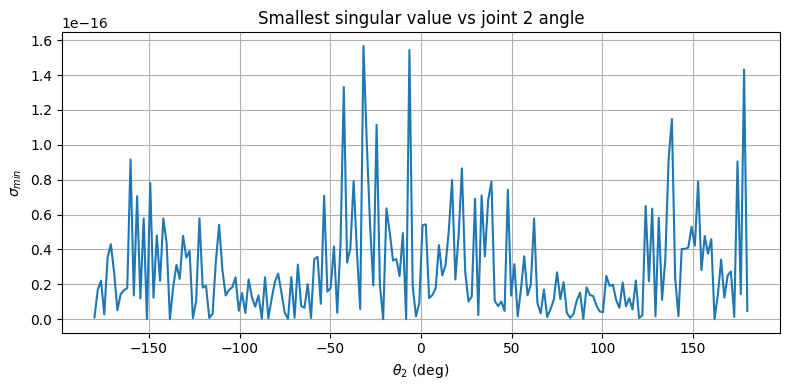

In [17]:
theta2_range = np.linspace(-np.pi, np.pi, 200)
sigma_min_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)   # base-frame Jacobian at the current sweep configuration
    _, sv, _ = np.linalg.svd(J_sweep)
    sigma_min_sweep[i] = sv[-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(theta2_range), sigma_min_sweep)
ax.set_xlabel(r'$\theta_2$ (deg)')
ax.set_ylabel(r'$\sigma_{min}$')
ax.set_title('Smallest singular value vs joint 2 angle')
ax.grid(True)
plt.tight_layout()
print('largest sigma_min over the whole sweep:', sigma_min_sweep.max())

**How it works / the answer is "everywhere"**
- `np.linspace(-π, π, 200)`: 200 evenly spaced angles; `np.zeros_like(a)`: an array of zeros with the shape of `a`;
  `for i, th2 in enumerate(...)` gives index and value together.
- **The curve is flat at zero: $\sigma_{min} \approx 10^{-16}$ for every $\theta_2$.** Not a mistake: with $q_3 = 0$
  the arm is **stretched**, which is singular no matter how the shoulder is turned (the elbow singularity depends on
  $q_3$ only). Turning joint 2 just moves a singular arm around.
- So the template's sweep, with all other joints at zero, cannot show *where* singularities occur. The next cell
  sweeps one joint at a time from a **healthy baseline** ($q_{ref}$) instead.

joint 2 dips at (deg): [-153.   27.]  sigma_min there: [0.0015 0.0015]
joint 3 dips at (deg): [-162.    0.   72.]  sigma_min there: [0.0006 0.     0.0007]
joint 5 dips at (deg): [-90.  90.]  sigma_min there: [0. 0.]


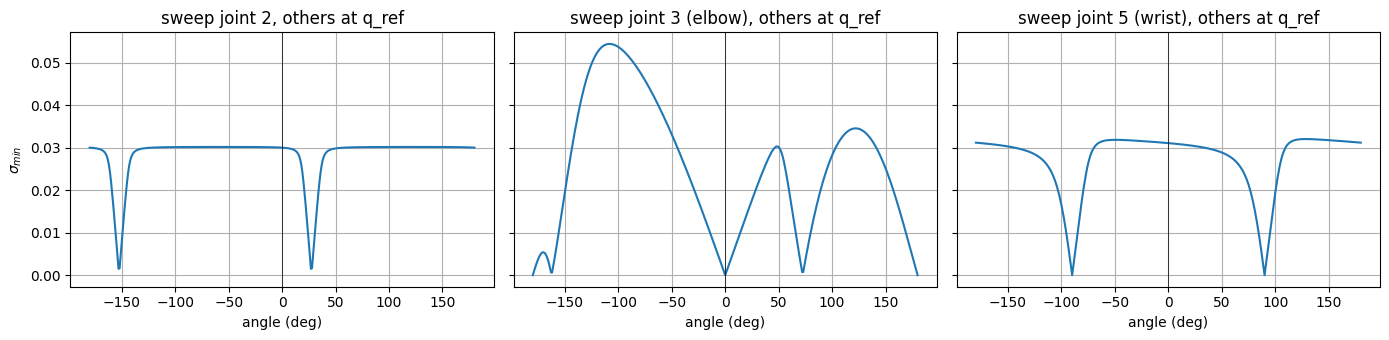

In [18]:
def sigma_min_of(q):
    return np.linalg.svd(mycobot.jacob0(np.asarray(q, dtype=float), end=bodyname))[1][-1]

sweep = np.linspace(-np.pi, np.pi, 361)
base = np.array([0.0, -np.pi/4, -np.pi/4, 0.0, np.pi/6, 0.0])    # q_ref: healthy baseline

def sweep_joint(j):
    out = np.zeros_like(sweep)
    for i, val in enumerate(sweep):
        q = base.copy()
        q[j] = val
        out[i] = sigma_min_of(q)
    return out

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, j, name in zip(axes, (1, 2, 4), ('joint 2', 'joint 3 (elbow)', 'joint 5 (wrist)')):
    s = sweep_joint(j)
    ax.plot(np.degrees(sweep), s)
    ax.axvline(0, color='k', lw=0.5); ax.grid(True)
    ax.set_title(f'sweep {name}, others at q_ref'); ax.set_xlabel('angle (deg)')
axes[0].set_ylabel(r'$\sigma_{min}$')
plt.tight_layout()

# Where are the dips? local minima below 0.01
for j, name in ((1, 'joint 2'), (2, 'joint 3'), (4, 'joint 5')):
    s = sweep_joint(j)
    idx = [i for i in range(1, len(s) - 1) if s[i] < s[i-1] and s[i] <= s[i+1] and s[i] < 0.02]
    print(name, 'dips at (deg):', np.round(np.degrees(sweep[idx]), 1), ' sigma_min there:', np.round(s[idx], 5))

**How it works / what you see**
- `zip(axes, (1, 2, 4), (...names))` walks through three lists in parallel. Joint indices are 0-based:
  1 = joint 2, 2 = joint 3, 4 = joint 5.
- `sharey=True` gives all three plots the same y-axis, so the depths are comparable.
- **Joint 3 (elbow):** $\sigma_{min}$ falls to exactly ≈ 0 at $q_3 = 0°$ (arm stretched). It also dips close to zero
  (≈ 0.0007) near $+72°$ and $-162°$: poses where the arm geometry lines up almost singularly (the second one
  is outside the joint limit ±150°).
- **Joint 5 (wrist):** exactly zero at $q_5 = \pm 90°$: joints 4 and 6 have parallel axes. Around $q_5 = 0$ the wrist is
  at its best. (In classical DH the offset of +90° moves this singularity to $\theta_5 = 0$; in the URDF's own joint
  numbers it sits at ±90°.)
- **Joint 2 (shoulder):** dips near −153° and +27° (with the elbow bent by −45°). They are near-singular, not exactly
  singular; where they lie depends on the other joints and on the link lengths.
- Lesson: on this robot avoid **q3 ≈ 0** (stretched arm) and **q5 ≈ ±90°** (wrist). $\sigma_{min}$ tells you how close
  you are.

---
## Manipulability
## Task 13: Yoshikawa manipulability
$$ w(q) = \sqrt{\det(J J^T)} = |\det J| \quad\text{(square } J\text{)} = \sigma_1\sigma_2\cdots\sigma_6 $$

In [19]:
def manipulability(J):
    return np.sqrt(max(np.linalg.det(J @ J.T), 0.0))   # max(.., 0): rounding can make det a tiny negative number

w_ref = manipulability(J0)             # manipulability at q_ref
w_singular = manipulability(J_singular)  # manipulability at the singular configuration

print(f'Manipulability at q_ref: {w_ref:.6e}')
print(f'Manipulability at q_singular: {w_singular:.6e}')
print('|det J| at q_ref (same for a square J):', abs(np.linalg.det(J0)))
print('product of singular values           :', np.prod(sigma))

Manipulability at q_ref: 1.604657e-03
Manipulability at q_singular: 7.650840e-17
|det J| at q_ref (same for a square J): 0.001604656606952907
product of singular values           : 0.0016046566069529056


**How it works**
- $\sqrt{\det(JJ^T)}$ is the volume of the **manipulability ellipsoid** (Task 15). For a square $J$,
  $\det(JJ^T) = (\det J)^2$, so $w = |\det J|$, and $|\det J| = \prod\sigma_i$: the three numbers printed at the
  bottom agree.
- `J @ J.T` is a symmetric positive semi-definite 6×6 matrix; its square root of the determinant is the volume factor.
  At a singularity the determinant is ±1e-33 instead of exactly 0; a tiny **negative** value would make `np.sqrt` return
  `nan`, hence the `max(det, 0.0)`.
- $w$ is zero at a singularity (last singular value 0) and larger the "rounder and bigger" the ellipsoid.
  Use $w$ to compare poses: prefer the one with the larger $w$.
- Caveat as before: $J$ mixes units, so absolute values of $w$ mean little; use it as a relative measure.

---
## Task 14: Manipulability sweep

max sigma_min: 1.5673450311636213e-16    max w: 2.7383746308041296e-10


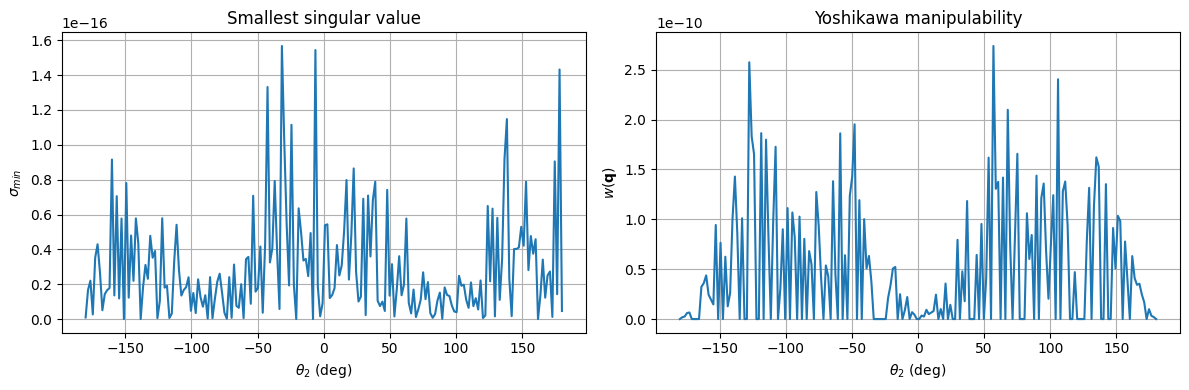

In [20]:
w_sweep = np.zeros_like(theta2_range)

for i, th2 in enumerate(theta2_range):
    q_sweep = np.array([0.0, th2, 0.0, 0.0, 0.0, 0.0])
    J_sweep = mycobot.jacob0(q_sweep, end=bodyname)   # base-frame Jacobian at the current sweep configuration
    w_sweep[i] = manipulability(J_sweep)              # manipulability for this configuration

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.degrees(theta2_range), sigma_min_sweep)
axes[0].set_xlabel(r'$\theta_2$ (deg)')
axes[0].set_ylabel(r'$\sigma_{min}$')
axes[0].set_title('Smallest singular value')
axes[0].grid(True)

axes[1].plot(np.degrees(theta2_range), w_sweep)
axes[1].set_xlabel(r'$\theta_2$ (deg)')
axes[1].set_ylabel(r'$w(\mathbf{q})$')
axes[1].set_title('Yoshikawa manipulability')
axes[1].grid(True)

plt.tight_layout()
print('max sigma_min:', sigma_min_sweep.max(), '   max w:', w_sweep.max())

**How it works / answer**
- As in Task 12, both quantities are essentially zero along the entire sweep ($\sigma_{min} \le 2\cdot10^{-16}$,
  $w \le 3\cdot10^{-10}$, printed above): $q_3 = 0$ makes the arm singular for every
  $\theta_2$, and $w$ (the product of all singular values) is zero as soon as one of them is.
- This is exactly the statement the task asks to verify: **$w$ is near zero wherever $\sigma_{min}$ is**. Here both are
  zero everywhere.
- Compare them along a sweep that does have structure, joint 3 from the healthy baseline:

correlation of the two curves: 0.767


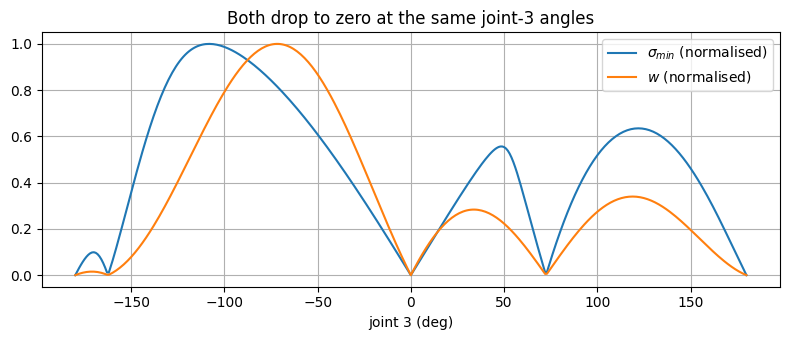

In [21]:
w3 = np.array([manipulability(mycobot.jacob0(np.r_[base[:2], v, base[3:]], end=bodyname)) for v in sweep])
s3 = sweep_joint(2)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.degrees(sweep), s3 / s3.max(), label=r'$\sigma_{min}$ (normalised)')
ax.plot(np.degrees(sweep), w3 / w3.max(), label=r'$w$ (normalised)')
ax.set_xlabel('joint 3 (deg)'); ax.legend(); ax.grid(True)
ax.set_title('Both drop to zero at the same joint-3 angles')
plt.tight_layout()
print('correlation of the two curves:', np.corrcoef(s3, w3)[0, 1].round(3))

- `np.r_[a, b, c]` concatenates arrays/scalars into one 1D array (here: joints 1–2, the swept value, joints 4–6).
- The list comprehension `[f(v) for v in sweep]` evaluates $w$ for every joint-3 value.
- Dividing by the maximum puts both curves on the same 0…1 scale. They dip together at the same angles.
  $w$ dips more sharply because it is a product of all the singular values.

---
## Task 15: Manipulability ellipsoid

semi-axis lengths (m/s per unit joint speed): [0.0672 0.2538 0.3093]
axis directions (columns):
 [[ 0.9853  0.1709  0.0036]
 [-0.171   0.9849  0.0284]
 [ 0.0013 -0.0286  0.9996]]


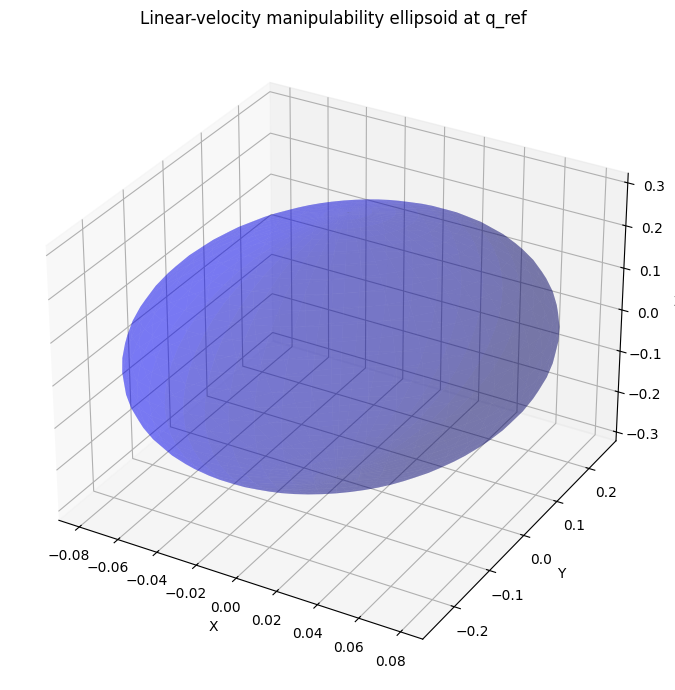

In [22]:
Jv = J0[:3, :]  # linear velocity rows
A = Jv @ Jv.T

# Eigendecomposition for the ellipsoid axes
eigenvalues, eigenvectors = np.linalg.eigh(A)

# Generate unit sphere points
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 30)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

# Transform sphere to ellipsoid
sphere_pts = np.stack([x_sphere.ravel(), y_sphere.ravel(), z_sphere.ravel()])
scale = np.diag(np.sqrt(np.maximum(eigenvalues, 0)))
ellipsoid_pts = eigenvectors @ scale @ sphere_pts

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(
    ellipsoid_pts[0].reshape(x_sphere.shape),
    ellipsoid_pts[1].reshape(y_sphere.shape),
    ellipsoid_pts[2].reshape(z_sphere.shape),
    alpha=0.3, color='b',
)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Linear-velocity manipulability ellipsoid at q_ref')
plt.tight_layout()

print('semi-axis lengths (m/s per unit joint speed):', np.sqrt(eigenvalues))
print('axis directions (columns):\n', eigenvectors)

**How it works (given code, explained)**
- **Idea:** if the joint velocities are limited to the **unit ball** $\lVert\dot q\rVert \le 1$, the reachable tool
  velocities form an ellipsoid $\{J_v\dot q\}$. Its shape shows in which directions the tool can move fast (long
  axes) and slowly (short axes).
- $A = J_vJ_v^T$ (3×3, symmetric). Its eigenvectors are the ellipsoid's **axis directions** and the square roots of the
  eigenvalues the **semi-axis lengths** (these are the singular values of $J_v$). `np.linalg.eigh` is the
  eigen-decomposition for symmetric matrices (returns ascending eigenvalues and orthonormal eigenvectors).
- The sphere: `np.linspace` makes the angle grids; `np.outer(a, b)` builds a 2D grid $a_ib_j$, so
  `x = cos(u) sin(v)`, `y = sin(u) sin(v)`, `z = cos(v)` traces a unit sphere.
- `np.stack([...])` puts the three flattened coordinate arrays into a 3×N matrix; `.ravel()` flattens a 2D array.
- `eigenvectors @ scale @ sphere_pts`: scale the sphere along the principal axes (by `sqrt(eigenvalues)`) and rotate
  it into place: sphere → ellipsoid. `np.maximum(eigenvalues, 0)` guards against tiny negative rounding errors before the
  square root.
- `plot_surface(X, Y, Z, ...)` needs 2D arrays, hence the `reshape`.
- **Reading it:** a long thin ellipsoid means the tool is fast in one direction and sluggish in the others. A sphere
  would be perfect. At a singularity one axis collapses to length 0 (the ellipsoid is flat).
- **Here** the semi-axes are 0.07, 0.25 and 0.31 (printed): the longest axes point along z and y, the shortest
  (0.07) along the base x-axis (eigenvector ≈ [0.99, −0.17, 0.00]). From this pose the tool moves easily up/down and
  sideways but only sluggishly straight out or in: reaching outward is where the arm is weakest.

---
## Resolved-rate velocity control
## Task 16: Integrate a constant twist
$$ q_{k+1} = q_k + J(q_k)^{-1}\,v_d\,\Delta t $$

In [23]:
dt = 0.05
t_final = 2.0
t_vec = np.arange(0, t_final + dt, dt)

# Desired Cartesian twist: gentle linear motion in x and z
v_desired = np.array([0.02, 0.0, -0.01, 0.0, 0.0, 0.05])  # m/s, rad/s

q_traj = np.zeros((len(t_vec), mycobot.n))
ee_pos = np.zeros((len(t_vec), 3))
q_traj[0, :] = q_ref.copy()
ee_pos[0, :] = mycobot.fkine(q_ref, end=bodyname).A[:3, 3]

for k in range(len(t_vec) - 1):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)      # base-frame Jacobian at the current trajectory point
    qdot_k = np.linalg.solve(J_k, v_desired)           # joint rates that produce the desired twist

    q_traj[k + 1, :] = q_traj[k, :] + qdot_k * dt
    ee_pos[k + 1, :] = mycobot.fkine(q_traj[k + 1], end=bodyname).A[:3, 3]

p_expected = ee_pos[0] + v_desired[:3] * t_final
print('start position (m)   :', ee_pos[0])
print('final position (m)   :', ee_pos[-1])
print('expected (p0 + v t)  :', p_expected)
print('final error (mm)     :', np.linalg.norm(ee_pos[-1] - p_expected) * 1000)

start position (m)   : [ 0.2472 -0.0408  0.1771]
final position (m)   : [ 0.2624 -0.0408  0.1476]
expected (p0 + v t)  : [ 0.2872 -0.0408  0.1571]
final error (mm)     : 26.625058291860395


**How it works**
- `np.arange(0, t_final + dt, dt)` = 0, 0.05, …, 2.0 (41 time points). `q_traj` and `ee_pos` are pre-allocated
  arrays (one row per time step); `q_traj[0, :] = ...` sets the first row.
- **Euler integration:** in each step, evaluate the Jacobian at the *current* joints, get the joint rates
  that would produce the wanted twist, and move the joints by rate × Δt. The Jacobian is re-evaluated every step
  because it changes as the arm moves.
- `qdot_k * dt`: rate times time step = joint change.
- **Result:** the tool does *not* end up where $p_0 + v\,t$ says: the error is centimetres. Task 18 shows why.

---
## Task 17: Plot the trajectory

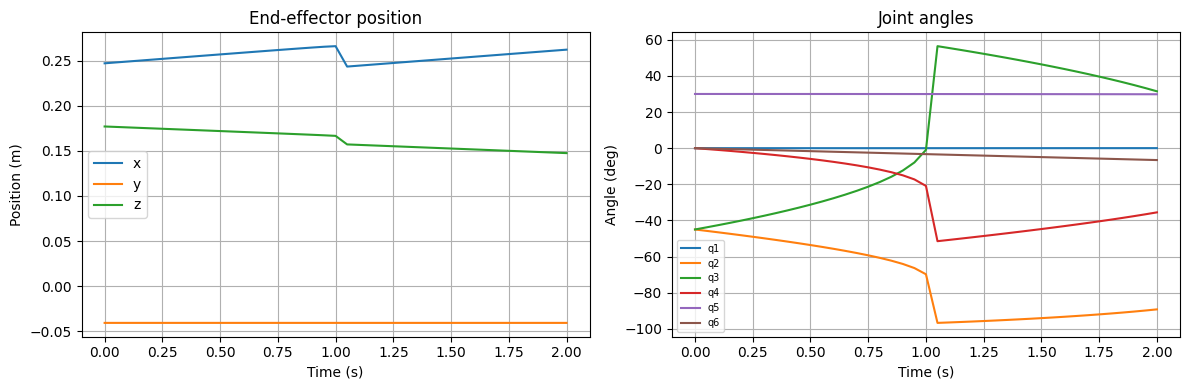

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t_vec, ee_pos[:, 0], label='x')
axes[0].plot(t_vec, ee_pos[:, 1], label='y')
axes[0].plot(t_vec, ee_pos[:, 2], label='z')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('End-effector position')
axes[0].legend()
axes[0].grid(True)

for j in range(mycobot.n):
    axes[1].plot(t_vec, np.degrees(q_traj[:, j]), label=f'q{j+1}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Angle (deg)')
axes[1].set_title('Joint angles')
axes[1].legend(fontsize=7)
axes[1].grid(True)

plt.tight_layout()

**How it works / what to see**
- `plt.subplots(1, 2, ...)`: two plots side by side; `axes[0]`, `axes[1]` address them.
- For a constant twist you expect straight lines: $x$ rising by 4 cm, $z$ falling by 2 cm in 2 s.
  Instead the position curves bend and the joint curves have a **jump** at $t \approx 1$ s (joint 3 changes by 57°
  between $t = 1.00$ and $1.05$ s, see the printout under Task 18). That jump is the signature of passing through the elbow singularity
  ($q_3 = 0$), where $J^{-1}$ explodes. Task 18 makes it visible in $w$.

---
## Task 18: Manipulability along the trajectory

smallest sigma_min on the path: 0.0007 at t = 1.00 s (q3 = -1.0 deg)
largest joint change in one step: 57.4 deg, joint 3, between t = 1.00 and 1.05 s


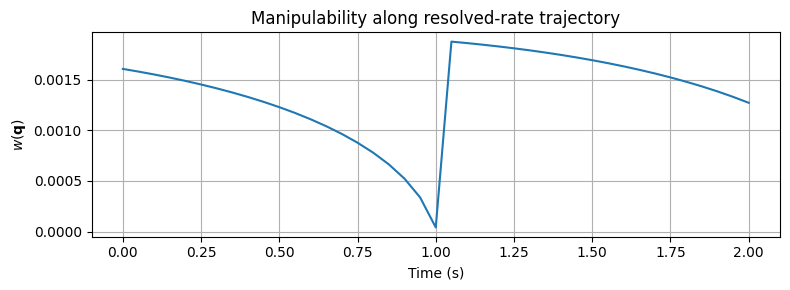

In [25]:
w_traj = np.zeros(len(t_vec))
sigma_traj = np.zeros(len(t_vec))

for k in range(len(t_vec)):
    J_k = mycobot.jacob0(q_traj[k], end=bodyname)   # base-frame Jacobian at the current trajectory point
    w_traj[k] = manipulability(J_k)                 # manipulability at this trajectory point
    sigma_traj[k] = np.linalg.svd(J_k)[1][-1]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_vec, w_traj)
ax.set_xlabel('Time (s)')
ax.set_ylabel(r'$w(\mathbf{q})$')
ax.set_title('Manipulability along resolved-rate trajectory')
ax.grid(True)
plt.tight_layout()

k_min = np.argmin(sigma_traj)
dq_all = np.degrees(np.abs(np.diff(q_traj, axis=0)))            # |joint change| per step and joint
k_jump, j_jump = np.unravel_index(dq_all.argmax(), dq_all.shape)
print(f'smallest sigma_min on the path: {sigma_traj[k_min]:.4f} at t = {t_vec[k_min]:.2f} s '
      f'(q3 = {np.degrees(q_traj[k_min, 2]):.1f} deg)')
print(f'largest joint change in one step: {dq_all.max():.1f} deg, joint {j_jump + 1}, between t = {t_vec[k_jump]:.2f} and {t_vec[k_jump+1]:.2f} s')

**How it works / answer**
- `np.argmin(a)` is the *index* of the smallest element; `np.diff(a, axis=0)` the difference between consecutive
  rows; `np.abs(...).max(axis=1)` the largest entry per row.
- **The manipulability drops to almost zero at t ≈ 1 s**, exactly where $q_3$ passes through 0: the trajectory runs
  into the elbow singularity. The joints then jump by more than 50° in one step. On a real robot this would be a
  violent, uncontrolled swing.
- **Lesson.** The wanted tool motion (forward and down) pushes the arm towards its stretched pose, where
  it can no longer follow. Resolved-rate control with the plain inverse is only safe far from singularities, so:
  monitor $\sigma_{min}$ or $w$, stop or slow down below a threshold, or use the damped inverse:

method                    final error [mm]  max joint step [deg]
plain J^-1                            26.6                  57.4
damped (lambda=0.02)                  18.8                   1.0
damped + feedback                     17.8                   1.8


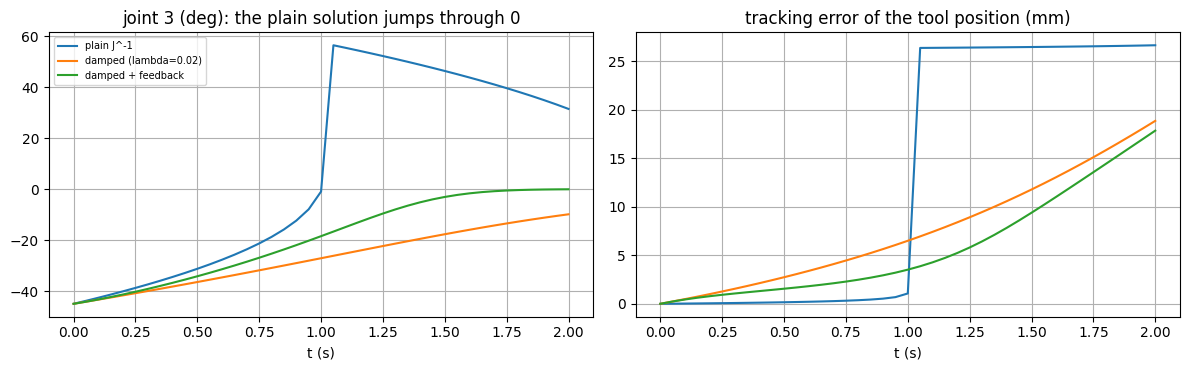

In [26]:
def resolved_rate(q_start, v_d, dt=0.05, t_final=2.0, damping=None, gain=0.0):
    """Euler integration of qdot = J^-1 v_d. damping=lambda uses the damped inverse; gain>0 adds position feedback."""
    t = np.arange(0, t_final + dt, dt)
    q = np.zeros((len(t), 6)); q[0] = q_start
    p = np.zeros((len(t), 3)); p[0] = mycobot.fkine(q_start, end=bodyname).A[:3, 3]
    for k in range(len(t) - 1):
        J = mycobot.jacob0(q[k], end=bodyname)
        v = v_d.copy()
        if gain > 0:
            v[:3] += gain * (p[0] + v_d[:3] * t[k] - p[k])          # feedback: pull towards the ideal path
        if damping is None:
            qd = np.linalg.solve(J, v)
        else:
            qd = J.T @ np.linalg.solve(J @ J.T + damping**2 * np.eye(6), v)
        q[k + 1] = q[k] + qd * dt
        p[k + 1] = mycobot.fkine(q[k + 1], end=bodyname).A[:3, 3]
    return t, q, p

runs = {
    'plain J^-1': resolved_rate(q_ref, v_desired),
    'damped (lambda=0.02)': resolved_rate(q_ref, v_desired, damping=0.02),
    'damped + feedback': resolved_rate(q_ref, v_desired, damping=0.02, gain=5.0),
}
target_end = ee_pos[0] + v_desired[:3] * t_final
print(f"{'method':24s} {'final error [mm]':>17s} {'max joint step [deg]':>21s}")
for name, (t_, q_, p_) in runs.items():
    print(f"{name:24s} {np.linalg.norm(p_[-1] - target_end)*1000:17.1f} {np.degrees(np.abs(np.diff(q_, axis=0))).max():21.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for name, (t_, q_, p_) in runs.items():
    axes[0].plot(t_, q_[:, 2] * 180 / np.pi, label=name)
    axes[1].plot(t_, [np.linalg.norm(a - (ee_pos[0] + v_desired[:3] * tt)) * 1000 for a, tt in zip(p_, t_)], label=name)
axes[0].set_title('joint 3 (deg): the plain solution jumps through 0'); axes[0].set_xlabel('t (s)'); axes[0].legend(fontsize=7); axes[0].grid(True)
axes[1].set_title('tracking error of the tool position (mm)'); axes[1].set_xlabel('t (s)'); axes[1].grid(True)
plt.tight_layout()

**How it works**
- `resolved_rate` is Task 16 as a function with two options:
  - `damping`: replaces $J^{-1}v$ by the damped form $J^T(JJ^T + \lambda^2I)^{-1}v$ from Lab 3. Near a singularity it
    gives up the impossible direction instead of producing huge joint rates.
  - `gain`: adds a **feedback** term. The Euler integration is open loop: errors accumulate. With `gain` the wanted
    linear velocity becomes $v + K(p_{ideal}(t) - p_{actual})$, so the tool is pulled back to the ideal straight line.
- **Result (fallback URDF):** the plain solution tracks the ideal path to about 1 mm until t = 1 s and then jumps (about 57° in one step), the damped versions change by about
  1–2° per step: smooth, safe. Their final error is still ~2 cm: **the requested motion is not achievable** past the
  elbow singularity, and damping merely trades accuracy for smoothness. To reach the goal, the path must avoid the
  singularity: use another start pose (`q3` well away from 0) or a different direction.
- `v[:3] += ...`: in-place addition to the first three entries; `v_d.copy()` avoids changing the caller's array.
- `runs.items()` with `for name, (t_, q_, p_) in ...` unpacks a dictionary entry whose value is itself a tuple.

---
## Bridge to the live controller (Tasks 19–20)
**These cells move the real arm. They were not executed here and stay off (`send_velocity = False`) until a person
switches them on.**

## Task 19: Velocity control via `/mycobot/joint_velocity`
From the controller code (`mycobot_control`), in short:
- `/mycobot/joint_velocity` (`Float64MultiArray`, 6 values, **rad/s**). Below **0.01 rad/s** per joint counts as zero
  (deadband); an all-zero vector triggers **stop**.
- Speed cap: 150°/s ≈ 2.618 rad/s. Acceleration ramp: at most 1.0 rad/s².
- The controller integrates the velocities into angle targets at 20 Hz and streams them to the servos.
- Consequence: as long as you keep publishing, the arm keeps moving. **If your notebook stops publishing without
  sending zeros, the last velocity may keep acting** (until the controller's own timeout). So always end with an
  explicit stop, and put it in a `finally:` block so an error cannot skip it.

In [ ]:
import time
import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)


class JacobianVelocityNode(Node):
    def __init__(self):
        super().__init__('jacobian_lab_node')
        self.vel_pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_velocity', 10)
        self.last_js = None
        self.js_sub = self.create_subscription(
            JointState, '/mycobot/joint_states', self._js_cb, 10,
        )

    def _js_cb(self, msg):
        self.last_js = msg

    def publish_velocity(self, qdot):
        msg = Float64MultiArray()
        msg.data = np.clip(qdot, -0.3, 0.3).tolist()   # lab safety cap 0.3 rad/s (controller allows 2.6)
        self.vel_pub.publish(msg)

    def stop(self):
        msg = Float64MultiArray()
        msg.data = [0.0] * 6
        self.vel_pub.publish(msg)


vel_node = JacobianVelocityNode()

**How it works**
- The node pattern is the same as in Labs 2 and 3 (subclass of `Node`, one subscription for the state, one publisher).
- `np.clip(qdot, -0.3, 0.3)`: the template clipped at ±2.6 rad/s, the controller's maximum. For first tests on the
  real robot this is far too fast; a 0.3 rad/s cap (17°/s) is used here instead.

---
## Task 20: Send a resolved-rate velocity command
Guards added to the template's cell (each one prevents a real failure):
1. `send_velocity = False` by default.
2. Refuse if the Jacobian is **close to singular** ($\sigma_{min} <$ 0.02): $J^{-1}$ would give huge rates.
3. Refuse if any joint rate is larger than the cap: the twist is too demanding for this pose.
4. Refuse if the joints would leave their limits **within the run time** (prediction $q + \dot q\,T$).
5. `try … finally` so **stop is always sent**, even after an error or Ctrl+C in the notebook.

In [ ]:
JOINT_LIMITS_DEG = np.array([[-168, 168], [-135, 135], [-150, 150], [-145, 145], [-165, 165], [-180, 180]])
QDOT_MAX = 0.3          # rad/s, lab cap
SIGMA_MIN_OK = 0.02

send_velocity = False   # a person sets this to True after reading the printout and checking the workspace

# Read current joint state
rclpy.spin_once(vel_node, timeout_sec=1.0)

if vel_node.last_js is not None:
    q_current = np.array(vel_node.last_js.position, dtype=float)
    print('Current q (rad):', q_current)

    # Jacobian at the current configuration (model of the real robot)
    J_current = mycobot.jacob0(q_current, end=bodyname)
    sigma_now = np.linalg.svd(J_current)[1][-1]

    # Desired twist: gentle x-direction motion (base frame), 2 cm/s
    v_cmd = np.array([0.02, 0.0, 0.0, 0.0, 0.0, 0.0])

    # Resolved rate
    qdot_cmd = np.linalg.solve(J_current, v_cmd)
    duration = 2.0
    q_end = q_current + qdot_cmd * duration
    lim = np.radians(JOINT_LIMITS_DEG)

    print('sigma_min:', round(sigma_now, 4), ' qdot (rad/s):', np.round(qdot_cmd, 3), ' predicted end q (deg):', np.round(np.degrees(q_end), 1))
    safe = (sigma_now >= SIGMA_MIN_OK
            and np.all(np.abs(qdot_cmd) <= QDOT_MAX)
            and np.all((q_end >= lim[:, 0]) & (q_end <= lim[:, 1])))
    print('checks passed:', safe)

    if send_velocity and safe:
        rate_hz = 20.0
        start = time.time()
        try:
            while time.time() - start < duration:
                vel_node.publish_velocity(qdot_cmd)
                rclpy.spin_once(vel_node, timeout_sec=0.0)
                time.sleep(1.0 / rate_hz)
        finally:
            vel_node.stop()
            print('Stopped.')
    else:
        print('not sent (send_velocity is False or a check failed)')
else:
    print('No joint state received. Is the controller running?')

# Optional cleanup:
# vel_node.destroy_node()
# rclpy.shutdown()

**How it works**
- `rclpy.spin_once(node, timeout_sec=1.0)` waits up to a second for the first joint state.
- The Jacobian is evaluated at the **measured** configuration (`q_current`). Using a stale `q_ref` would give joint
  rates for the wrong arm pose.
- `qdot_cmd * duration` is the predicted joint displacement of a constant-rate run; comparing it with the limits
  uses the same broadcasting idea as before (`(q >= lo) & (q <= hi)` element-wise, `np.all` = every joint).
- `while time.time() - start < duration:` publishes at 20 Hz for 2 s. The controller only reads the topic when
  something is published; `spin_once(..., 0.0)` lets our own subscription keep receiving the state meanwhile.
- The `try … finally:` block guarantees the zero-velocity **stop** message is sent even if the loop raises an
  error.
- Because the model (URDF) and the real robot differ slightly, and the velocity is applied open loop for 2 s,
  the tool moves *approximately* 4 cm along x. Check the real motion against the measured pose afterwards.

---
## Summary
- $v = J\dot q$; columns are $z_i\times(p_e-p_i)$ over $z_i$; `jacob0` = base frame, `jacobe` = tool frame.
- Resolved rate: $\dot q = J^{-1}v$ (use `solve`), Euler integration $q_{k+1} = q_k + \dot q\,\Delta t$, open loop.
- Singularities: rank drop, $\sigma_{min}\to0$, $w\to0$. On the myCobot: **$q_3 \approx 0$ (elbow stretched) and
  $q_5 \approx \pm 90°$ (wrist)**. Sweeping only joint 2 from an all-zero pose hides where they are: that pose is
  already singular.
- Near a singularity: monitor $\sigma_{min}$/$w$, use damped inverse, keep feedback, and never send unchecked
  velocities to the real robot.